# Lecture 1: Vector spaces

The name of the quantum game are complex inner product spaces and matrices, so we better spend some time really getting familiar with them.

## Vectors abstractly

The idea of vectors are incredibly powerful and form a pillar of mathematics. In the most general sense, vectors are objects where you are allowed to do two operations:
- there is a notion of $+$, where you can add two vectors.
- there is a notion of multiplying by a number: $x\cdot\lambda$ makes sense if $x$ is a vector and $\lambda$ is a number.

We call the product $\cdot$ the *scalar* product and we refer to the numbers in $\mathbb{R}$ as *scalars*. The skeleton of every vector class looks like the following:

In [1]:
from abc import ABC, abstractmethod

class VectorSpace(ABC):
    @abstractmethod
    def __add__(self,other: VectorSpace) -> VectorSpace:
        """
        Adds two vectors together.
        :param self:
        :param other:
        :return: self+other
        """
        pass

    @abstractmethod
    def __mul__(self, scalar: float) -> VectorSpace:
        """
        Multiplies a vector by a scalar
        :param scalar:
        :param self:
        :return: self*scalar
        """
        pass

    # These two functions come for free once + and * are defined.
    def __neg__(self):
        """
        Takes negative of a vector
        :return: self*(-1)
        """
        return self*(-1)

    def __sub__(self, other: VectorSpace) -> VectorSpace:
        """
        Takes the difference between two vectors
        :param self:
        :param other:
        :return: self+(-other)
        """
        return self+(other*(-1))


There are some rules that these operations need to meet the spec of being vectors, but before we get to those rules, let's see some examples.


### Example: the collection of numbers are vectors
Consider the collection $\mathbb{R}$ of all real numbers (all the numbers on the number line). We can treat these as vectors since there is a notion of $+$ and a notion of multiplication.

In [2]:
class RealNumber(VectorSpace):
    def __init__(self, value: float):
        self.value = value

    def __add__(self,other: RealNumber) -> RealNumber:
        return RealNumber(self.value+other.value)

    def __mul__(self, scalar: float) -> RealNumber:
        return RealNumber(self.value*scalar)

    def __str__(self) -> str:
        return str(self.value)

    def __eq__(self, other: RealNumber) -> bool:
        return self.value==other.value

    def __ne__(self, other: RealNumber) -> bool:
        return not self.__eq__(other)

In [3]:
x = RealNumber(4)
print(x*3)

12


 ### Example: pairs are vectors
Consider the collection $(a,b)$ of pairs of numbers. We can define $+$ by $(a,b)+(c,d) = (a+c, b+d)$ and define multiplication by a number by $(a,b)\cdot\lambda = (a\cdot \lambda, b\cdot\lambda)$. This makes pairs into vectors. We can do the same thing to make triplets vectors, and quadruplets as vectors, etc. However, we do not usually allow adding different sized tuples as vectors: $(a,b)+(c,d,e)$ is usually not defined.

In [4]:
class Pair(VectorSpace):
    def __init__(self, left, right):
        self.left = left
        self.right = right

    def __add__(self,other: Pair) -> Pair:
        return Pair(left=self.left+other.left,
                    right=self.right+other.right)

    def __mul__(self, scalar: float) -> Pair:
        return Pair(left=self.left*scalar,
                    right=self.right*scalar)

    def __str__(self) -> str:
        return f'({self.left},{self.right})'

    def __eq__(self, other: Pair) -> bool:
        return self.left == other.left and self.right == other.right

    def __ne__(self, other: Pair) -> bool:
        return not self.__eq__(other)

In [5]:
x = Pair(2,4)
y = Pair(1,-3)
print(x+y)

(3,1)



### Example: matrices are vectors
A matrix is just a grid of numbers. Consider the collection of $2 \times 2$ matrices:
$$
    \left[ \begin{array}{cc} a & b \\ c & d \end{array} \right]
$$
where $a,b,c,d$ are numbers. We can define $+$ and multiplying by a number in the same way as pairs:
$$
    \left[ \begin{array}{cc} a_1 & b_1 \\ c_1 & d_1 \end{array} \right] + \left[ \begin{array}{cc} a_2 & b_2 \\ c_2 & d_2 \end{array} \right] = \left[ \begin{array}{cc} a_1 + a_2 & b_1 + b_2 \\ c_1 + c_2 & d_1 + d_2 \end{array} \right]
$$
and
$$
    \left[ \begin{array}{cc} a & b \\ c & d \end{array} \right]\cdot\lambda = \left[ \begin{array}{cc} a\lambda  & b\lambda \\ c\lambda & d\lambda \end{array} \right] \;.
$$

In general, we can define vector operations for any $m \times n$ matrix: a grid of numbers with $m$ rows and $n$ columns. For example, for $3 \times 2$ matrices:
$$
    \left[ \begin{array}{cc} a & b \\ c & d \\ e & f \end{array} \right]
$$
we have the rules
$$
    \left[ \begin{array}{cc} a_1 & b_1 \\ c_1 & d_1 \\ e_1 & f_1 \end{array} \right] + \left[ \begin{array}{cc} a_2 & b_2 \\ c_2 & d_2 \\ e_2 & f_2 \end{array} \right] = \left[ \begin{array}{cc} a_1 + a_2 & b_1 + b_2 \\ c_1 + c_2 & d_1 + d_2 \\ e_1+e_2 & f_1 + f_2 \end{array} \right]
$$
and
$$
    \left[ \begin{array}{cc} a & b \\ c & d \\ e & f \end{array} \right]\cdot\lambda = \left[ \begin{array}{cc} a\lambda & b\lambda \\ c\lambda & d\lambda \\ e\lambda & f\lambda \end{array} \right] \;.
$$

We give an implementation of $3 \times 2$ matrices next.

In [6]:
class Matrix32(VectorSpace):
    def __init__(self, row1: list[float], row2: list[float], row3: list[float]):
        if any([len(row) != 2 for row in [row1, row2, row3]]):
            raise ValueError('Incorrect dimensions')

        self.row1=row1
        self.row2=row2
        self.row3=row3

    def __add__(self,other: Matrix32) -> Matrix32:
        return Matrix32(
            row1=[self.row1[0]+other.row1[0], self.row1[1]+other.row1[1]],
            row2=[self.row2[0]+other.row2[0], self.row2[1]+other.row2[1]],
            row3=[self.row3[0]+other.row3[0], self.row3[1]+other.row3[1]]
        )

    def __mul__(self, scalar: float) -> Matrix32:
        return Matrix32(
            row1=[self.row1[0]*scalar, self.row1[1]*scalar],
            row2=[self.row2[0]*scalar, self.row2[1]*scalar],
            row3=[self.row3[0]*scalar, self.row3[1]*scalar]
        )

    def __str__(self) -> str:
        return (f'{self.row1}\n{self.row2}\n{self.row3}')

    def __eq__(self, other: Matrix32) -> bool:
        return (self.row1 == other.row1
                and self.row2 == other.row2
                and self.row3 == other.row3)

    def __ne__(self, other: Matrix32) -> bool:
        return not self.__eq__(other)

We also have the class of $2 \times 2$ matrices

In [7]:
class Matrix22(VectorSpace):
    def __init__(self, row1: list[float], row2: list[float]):
        if any([len(row) != 2 for row in [row1, row2]]):
            raise ValueError('Incorrect dimensions')

        self.row1=row1
        self.row2=row2

    def __add__(self,other: Matrix22) -> Matrix22:
        return Matrix22(
            row1=[self.row1[0]+other.row1[0], self.row1[1]+other.row1[1]],
            row2=[self.row2[0]+other.row2[0], self.row2[1]+other.row2[1]]
        )

    def __mul__(self, scalar: float) -> Matrix22:
        return Matrix22(
            row1=[self.row1[0]*scalar, self.row1[1]*scalar],
            row2=[self.row2[0]*scalar, self.row2[1]*scalar]
        )

    def __str__(self) -> str:
        return (f'{self.row1}\n{self.row2}')

    def __eq__(self, other: Matrix22) -> bool:
        return (self.row1 == other.row1
                and self.row2 == other.row2)

    def __ne__(self, other: Matrix22) -> bool:
        return not self.__eq__(other)

In [8]:
A = Matrix32(
    row1=[1,1],
    row2=[2,2],
    row3=[4,3]
)
B = Matrix32(
    row1=[-1,0],
    row2=[0,1],
    row3=[-4,3]
)
print(A+B)

[0, 1]
[2, 3]
[0, 6]



### Example: polynomials are vectors
Remember that a quadratic is a function of the form
$$
    f(x) = a + bx +cx^2
$$
where $a,b,c$ are numbers. We can add and multiply quadratics by
$$
    (a_1 + b_1x + c_1 x^2) + (a_2 + b_2x + c_2 x^2) = (a_1+a_2) + (b_1+b_2)x + (c_1+c_2)x^2
$$
and
$$
    (a + bx + cx^2)\cdot\lambda = (a\lambda) + (b\lambda)x + (c\lambda)x^2  \;.
$$
Notice that there is no real difference mechanically between how $+$ and $\cdot$ behave on quadratics vs on triplets: we can treat $(a,b,c)$ and $a+bx+cx^2$ as the same object if we are only concerned with how to add or multiply by a number. In general, we can apply the $+$ and multiplication rules for degree $d$ polynomials by treating $a_0+a_1x +a_2 x^2 + \cdots + a_d x^d$ as the $d+1$-tuple $(a_0,a_1,\cdots, a_d)$. In fact, all of the examples so far can be reduced to some kind of tuple: for example, mechanically, calculating vector operations for this:
$$
    \left[ \begin{array}{cc} a & b \\ c & d \end{array} \right]
$$
is no different from calculating vector operations for the tuple $(a,b,c,d)$. The reason for introducing these other examples are because they will have other operations that are easier to understand in their presented form than as a tuple. For example, it makes sense to multiply two linear functions to make a quadratic:
$$
    (a+bx)\cdot(c+dx) = ac + (bc+ad)x + bdx^2
$$
but presenting this multiplication with tuples would create the less intuitive rule
$$
    (a,b,0)\cdot(c,d,0) = (ac,bc+ad, bd) \;.
$$

In [9]:
class Quadratic(VectorSpace):
    def __init__(self,constant: float, linear: float, quadratic: float):
        self.constant=constant
        self.linear=linear
        self.quadratic=quadratic

    def __add__(self, other: Quadratic) -> Quadratic:
        return Quadratic(constant=self.constant+other.constant,
                         linear=self.linear+other.linear,
                         quadratic=self.quadratic+other.quadratic)

    def __mul__(self, scalar: float) -> Quadratic:
        return Quadratic(constant=self.constant*scalar,
                         linear=self.linear*scalar,
                         quadratic=self.quadratic*scalar)

    def __str__(self) -> str:
        return f'{self.constant}+{self.linear}x+{self.quadratic}x^2'

    def __eq__(self, other: Quadratic) -> bool:
        return (self.constant==other.constant
                and self.linear==other.linear
                and self.quadratic==other.quadratic)

    def __ne__(self, other: Quadratic) -> bool:
        return not self.__eq__(other)

In [10]:
p=Quadratic(1,2,3)
print(p)
q=Quadratic(-1,2,-2)
print(q)
print(p+q*0.5)

1+2x+3x^2
-1+2x+-2x^2
0.5+3.0x+2.0x^2


### The axioms of vector spaces

Any collection of vectors where $+$ and multiplication by a number makes sense is called a *vector space*. For example, we have seen that the collection
$$
    \{ (a,b) : a,b \in \mathbb{R}\}
$$
of pairs of numbers is a vector space, while the collection
$$
    \{(a,b), (a,b,c): a,b,c \in \mathbb{R}\}
$$
consisting of pairs *and* triplets is not (because $(a,b)+(c,d,e)$ is not defined).

The axioms of vector spaces are many but they're all the things you would expect $+$ and $\lambda$ to do:
- $+$ should not care about brackets (also called *associativity*) $(x+y)+z = x+(y+z)$. So, $x+y+z$ makes sense and is not ambiguous.
- $+$ is commutative: $x+y = y+x$.
- There is a vector $0$ so that $x+0 = x$ for any vector $x$.
- Multiplication should not care about brackets $x\cdot(\lambda \cdot \mu)= (x\cdot\lambda)\cdot\mu$. So, $x\cdot\lambda \cdot \mu$ makes sense and is not ambiguous.
- The usual distributive rules hold:
$$
    x\cdot(\lambda +\mu) = x\cdot\lambda + x\cdot\mu\text{ and } (x+y)\cdot\lambda = x\cdot\lambda + y\cdot\lambda \;.
$$
- $x\cdot 1 = x$ and $x\cdot 0 = 0$.

**Warning**: Remember that $0$ in the context of the zero vector (third bullet point) is *not* the number $0$. We will see some examples to demonstrate this.

From the axioms, it follows that we can always subtract elements.

**Theorem**: Every element $x$ in a vector space has a *unique* negative $y$ so that $x+y = 0$. It satisfies the identity $y = x\cdot(-1)$.

**Proof**: Notice that $x+ x\cdot(-1) = x\cdot 1 + x\cdot(-1) = x\cdot(1 + (-1)) = x\cdot 0 = 0$. So, $x\cdot(-1)$ works as a negative.
Suppose there is another vector $y$ that also satisfies $x+y = 0$. Then
$$
\begin{align*}
    x\cdot(-1) + x + y &= (x\cdot(-1)+x)+y \\
    &= 0+y \\
    &= y 
\end{align*}
$$
but on the other hand, 
$$
\begin{align*}
    x\cdot(-1)+ x + y &= x\cdot(-1) + (x+y) \\
    &= x\cdot(-1) + 0 \\
    &= x\cdot(-1) \;.
\end{align*}
$$
So, $y = x\cdot(-1)$.

We write $x-y$ to mean $x+(-y)$.



## Exercises on the axioms of vector spaces.
We need to do lots of exercises to solidify our understanding. In these exercises, $+$ might not mean what you usually think of as $+$, so we use the notation $\boxplus$ to denote the $+$ operation in a vector space. We also use these exercises as a way of establishing some more notation.

### Exercise 1
Consider the vector space $\mathbb{R}$ of real numbers. We let $\boxplus$ and $\cdot$ be the usual addition and multiplication of numbers:
- $a \boxplus b = a+b$ and
- $a\cdot \lambda = a\lambda$.

1. Show that the number $0$ is the zero vector (what does it mean to show that $0$ is the zero vector?).
2. Given a real number $x$, show that $-x$ is the inverse: that is, $x\boxplus(-x) = 0$.

In [11]:
zero = RealNumber(0)
x = RealNumber(37)
y= RealNumber(-37)
print(x+y)

0


### Exercise 2
Let $\mathbb{R}^2$ denote the collection of pairs of real numbers $(a,b)$. We let $\boxplus$ and $\cdot$ be the operations that we have defined before. That is,
- $(a,b)\boxplus (c,d) = (a+c, b+d)$ and
- $(a,b)\cdot\lambda = (a\cdot\lambda, b\cdot\lambda)$.


1. **Test that you understand $\boxplus$**: Evaluate $(1,2)\boxplus(-1,3)$.
2. Find the zero vector $0$ and show that $(a,b)\boxplus 0 = (a,b)$ for any pair $(a,b)$.
3. Verify that $(a,b)\cdot 0 = 0$.
4. Find $-(a,b)$ and show that $(a,b)\boxplus(-(a,b)) = 0$.

Sometimes it will be useful to visualize elements of $\mathbb{R}^2$ as line segments starting at $(0,0)$ and ending at $(a,b)$. Below are some examples.

In [12]:
a,b =1,2
x=Pair(a,b)
y=Pair(-a,-b)
print(f'{x+y}={Pair(0,0)}')

(0,0)=(0,0)


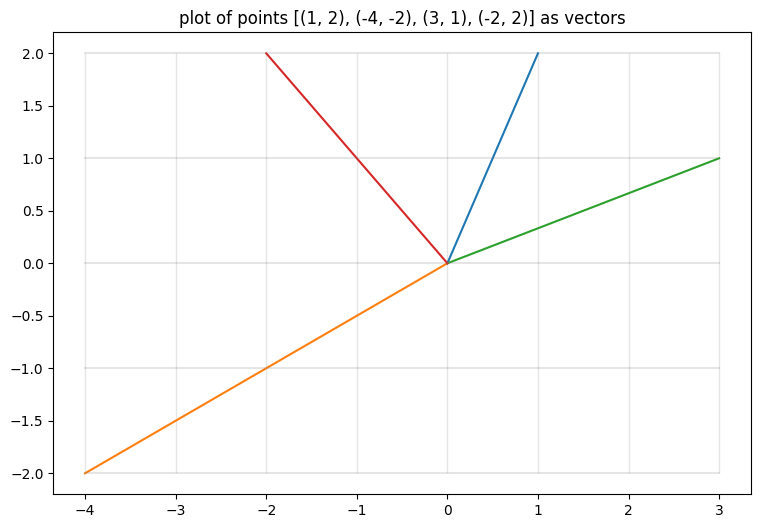

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

points = [(1,2), (-4,-2), (3,1), (-2,2)]
plt.figure(figsize=(9,6))
plt.title(f'plot of points {points} as vectors')
for pt in points:
    sns.lineplot(x=[0, pt[0]], y=[0, pt[1]])
x_min = min([pt[0] for pt in points])
x_max = max([pt[0] for pt in points])
y_min = min([pt[1] for pt in points])
y_max = max([pt[1] for pt in points])
for y in range(y_min, y_max+1):
    sns.lineplot(x=[x_min, x_max], y=[y,y], c='gray', alpha=0.2)
for x in range(x_min, x_max+1):
    sns.lineplot(x=[x,x], y=[y_min, y_max], c='gray', alpha=1)
plt.show()

**Question** Which colours correspond to which pair?

One way to picture how adding pairs work is by observing that evaluating $(a,b)+(c,d)$ is like 'connecting line segments', which I illustrate below:

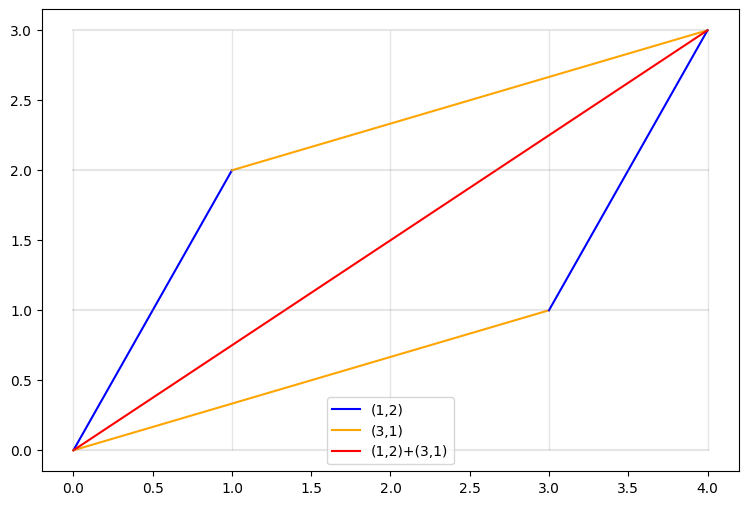

In [14]:
points = [(1,2), (3,1)]
plt.figure(figsize=(9,6))
sns.lineplot(x=[0, 1], y=[0, 2], c='blue', label='(1,2)')
sns.lineplot(x=[1,1+3], y=[2, 2+1], c='orange', label='(3,1)')

sns.lineplot(x=[0,3], y=[0,1], c='orange')
sns.lineplot(x=[3,3+1], y=[1,1+2], c='blue')

sns.lineplot(x=[0,1+3], y=[0, 2+1], c='red', label='(1,2)+(3,1)')

for y in range(0, 3+1):
    sns.lineplot(x=[0, 4], y=[y,y], c='gray', alpha=0.2)
for x in range(0, 4+1):
    sns.lineplot(x=[x,x], y=[0, 3], c='gray', alpha=1)

plt.show()

This also gives a pictorial demonstration of why $(a,b)+(c,d) = (c,d)+(a,b)$.

#### How pairs work in python
Tuples in python have $+$ defined by concatenation, so $(1,2)+(3,4) = (1,2,3,4)$. Note that $+$ defined in this way is not commutative: $(1,2)+(3,4) \neq (3,4)+(1,2)$ and therefore $+$ is not a vector space operation.

In python, the correct way to handle tuples is to use numpy's array class. Below I demonstrate some examples.

In [15]:
# Some sample calculations using numpy's array class to show it works the way you expect.
import numpy as np

# Adding (1,2) with (3,4):
print(f'[1,2] + [3,4] = {np.array([1,2]) + np.array([3,4])}')

# Scalar products also behave correctly.
print(f'[5,-6]*2 = {np.array([5,-6])}*2')

[1,2] + [3,4] = [4 6]
[5,-6]*2 = [ 5 -6]*2


### Exercise 3
Let $M_{2,2}(\mathbb{R})$ denote the collection of $2 \times 2$ matrices with coefficients in $\mathbb{R}$. Here $\boxplus$ and $\cdot$ are the rules presented earlier.
1. **Test that you understand $\boxplus$**: Evaluate
$$
    \left[\begin{array}{cc} 1 & 2 \\ -2 & 1 \end{array} \right] \boxplus \left[\begin{array}{cc} 0 & 1 \\ 2 & 3 \end{array} \right] \;.
$$
2. Find the zero vector $0$ and show that
$$
    \left[\begin{array}{cc} a & b \\ c & d \end{array} \right] \boxplus 0 = \left[\begin{array}{cc} a & b \\ c & d \end{array} \right] \;.
$$
3. If $A \in M_{2,2}(\mathbb{R})$, find $-A$ and show that $A\boxplus(-A) = 0$.

In [16]:
A = Matrix22([1,2],
             [-2,1])
zero = Matrix22([0,0],
             [0,0])
B = Matrix22([-1,-2],
             [2,-1])
print(A+B)

[0, 0]
[0, 0]


Matrices in numpy are coded up as arrays of arrays. Below are some calculations done with numpy so you can see how they work. Note that notationally, we will use capital letters to denote matrices.

In [17]:
import sympy as sp #sympy is to print the matrices in pretty latex
sp.init_printing(use_latex=True)

A = np.array([[ 1, 2],
              [-2, 1]])
B = np.array([[ 6, 7],
              [-7, 6]])

print('A =')
display(sp.Matrix(A))
print('B = ')
display(sp.Matrix(B))
print('A+B = ')
display(sp.Matrix(A+B))

# The numpy zero matrix is written as
zero = np.zeros(shape=(2,2))
print('A+0 =')
display(sp.Matrix(A+zero))

A =


⎡1   2⎤
⎢     ⎥
⎣-2  1⎦

B = 


⎡6   7⎤
⎢     ⎥
⎣-7  6⎦

A+B = 


⎡7   9⎤
⎢     ⎥
⎣-9  7⎦

A+0 =


⎡1.0   2.0⎤
⎢         ⎥
⎣-2.0  1.0⎦

### Example: Images as vectors
Here we're going to look at a model of images as vectors. In python one way to store an image is as a grid of RGB values. Suppose we have an $m$-pixel by $n$-pixel image. We could store all the red pixel values by a matrix $\text{Red} \in M_{m,n}(\mathbb{R})$, all the green pixel values by a matrix $\text{Green} \in M_{m,n}(\mathbb{R})$, and all the blue pixel values by a matrix $\text{Blue} \in M_{m,n}(\mathbb{R})$. In general, we can define a vector space
$$
    \text{Image}_{m,n} = \{(R,G,B): R, G, B \in M_{m,n}(\mathbb{R}) \}
$$
where addition $\boxplus$ and scalar multiplication $\cdot$ are given coordinate-wise:
$$
    (R_1, G_1, B_1) \boxplus (R_2, G_2, B_2) = (R_1+R_2, G_1+G_2, B_1+B_2) \text{ and } (R,G,B)\cdot\lambda = (R\cdot\lambda, G\cdot\lambda, B\cdot\lambda)\;.
$$
We give a python implementation of this image class.

In [18]:
import matplotlib.pyplot as plt
from numpy.typing import NDArray
HEIGHT = 242
WIDTH = 379
class ImageVector(VectorSpace):
    def __init__(self, red : NDArray[np.float64], green: NDArray[np.float64], blue: NDArray[np.float64]):
        if any([x.shape != (HEIGHT,WIDTH) for x in [red, green, blue]]):
            raise ValueError(f'Arrays must be of size ({HEIGHT},{WIDTH})')
        self.red=red
        self.green=green
        self.blue=blue

    # Redefine + to do the vector addition.
    def __add__(self, other: ImageVector) -> ImageVector:
        return ImageVector(
            red = self.red+other.red,
            green=self.green+other.green,
            blue=self.blue+other.blue)

    # Scalar multiply a vector by a number 'scalar'.
    def __mul__(self, scalar: float) -> ImageVector:
        return ImageVector(
            red=self.red*scalar,
            green=self.green*scalar,
            blue=self.blue*scalar)

    def __str__(self):
        # We first clip the values of our vector between 0 and 255
        def clip_vals(pixel: float) -> int:
            pixel = int(np.floor(pixel)) # first approximate the float to an integer
            if pixel < 0:
                return 0
            elif pixel > 255:
                return 255
            else:
                return pixel

        red_vals = np.vectorize(clip_vals)(self.red)
        blue_vals = np.vectorize(clip_vals)(self.blue)
        green_vals = np.vectorize(clip_vals)(self.green)

        rgb_matrix = np.array([red_vals.T, green_vals.T, blue_vals.T]).T #This is just to correct a convention by imshow.
        plt.imshow(rgb_matrix)
        plt.axis('off')
        plt.show()
        return ''

    def __eq__(self, other: ImageVector) -> bool:
        return (self.red == other.red
                and self.green == other.green
                and self.blue == other.blue)

    def __ne__(self, other: ImageVector) -> bool:
        return not self.__eq__(other)

Here are two images that I drew. Let's look at what happens when we add them together.

[[255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 ...
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]]


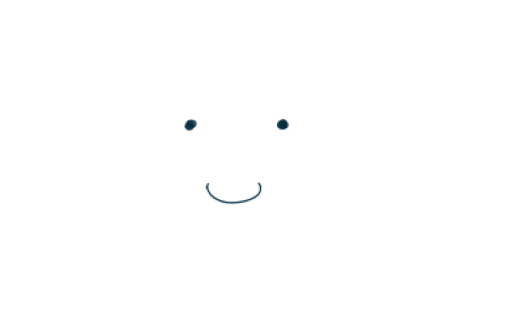

In [19]:
from PIL import Image

img_kalm = np.asarray(Image.open('data/kalm.jpg'))
kalm_red = img_kalm[:,:,0].astype(float)
print(kalm_red)
kalm_green = img_kalm[:,:,1].astype(float)
kalm_blue = img_kalm[:,:,2].astype(float)
kalm_vector = ImageVector(kalm_red, kalm_green, kalm_blue)
print(kalm_vector)

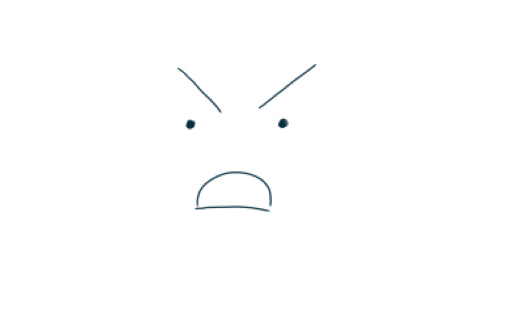

In [20]:
img_panik = np.asarray(Image.open('data/panik.jpg'))
panik_red = img_panik[:,:,0].astype(float)
panik_green = img_panik[:,:,1].astype(float)
panik_blue = img_panik[:,:,2].astype(float)
panik_vector = ImageVector(panik_red, panik_green, panik_blue)
print(panik_vector)

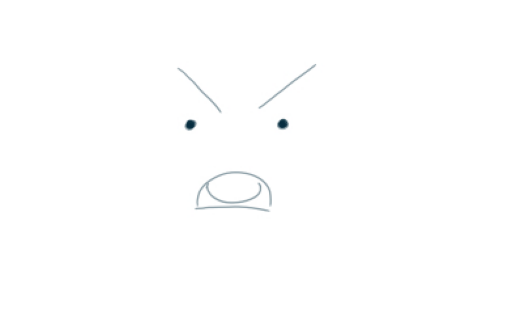

In [21]:
print((kalm_vector+panik_vector)*0.5)

The zero vector is the 'all black' image.

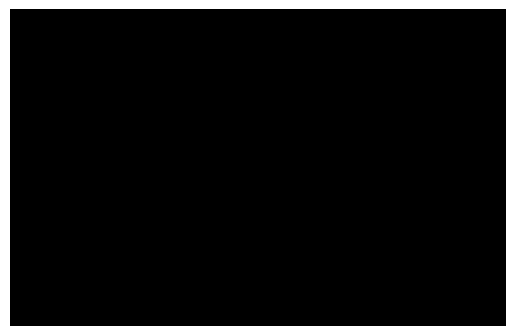

In [22]:
zero_vector = ImageVector(red=np.zeros((HEIGHT,WIDTH)), blue=np.zeros((HEIGHT,WIDTH)), green=np.zeros(shape=(HEIGHT,WIDTH)))
print(zero_vector)

Another relevant vector is the vector with 255 in all of its coordinates.

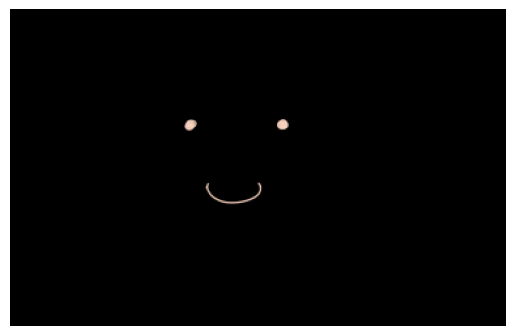

In [23]:
bright_vector = ImageVector(red=np.ones((HEIGHT,WIDTH))*255, blue=np.ones((HEIGHT,WIDTH))*255, green=np.ones(shape=(HEIGHT,WIDTH))*255)
print(bright_vector-kalm_vector)

### Exercise 4
Let $P_2(x, \mathbb{R})$ denote the collection of quadratics with coefficients in $\mathbb{R}$ and unknown variable $x$. The operations $\boxplus$ and $\cdot$ are the rules presented earlier. 
1. **Test that you understand $\boxplus$**: Evaluate $(-2 + x^2) \boxplus (1+6x)$.
2. Show that the $0$-polynomial $p(x) = 0$ is the zero vector.
3. Given $f(x) = a + bx + cx^2$, find $-f(x)$ and verify that $f(x)\boxplus(-f(x)) = 0$.

The package sympy let us handle polynomials. Below is an example in python.

In [24]:
p = Quadratic(-2,3,1)
q = Quadratic(2,-3,-1)
print(p+q)

0+0x+0x^2


In [25]:
from sympy import symbols
x = symbols('x')

# We use the unknown 'x' like any variable.
f = 1+x+2*x**2
g = 6-5*x**2
print('f=')
display(f)

print('g=')
display(g)

print('f+g=')
display(f+g)

f=


g=


f+g=


### Exercise 5
In this example, we give an example of something with a $\boxplus$ and $\cdot$ but that is *not* a vector space. Let $\mathbb{R}^{\mathbb{R}}$ denote the set of functions with input $\mathbb{R}$ and output $\mathbb{R}$. Define $\boxplus$ by composition: $(f\boxplus g)(x) = f(g(x))$ and define $\cdot$ by scaling the output: $(f \cdot \lambda)(x) = f(x) \cdot \lambda$.
1. **Test that you understand $\boxplus$**: let $f(x) = 1+x^3$ and $g(x) = x^2+6$. Evaluate $(f\boxplus g)(1)$.
2. **Test that you understand $\boxplus$**: let $f(x) = x^2$ and let $g(x) = \sin(x)$. Evaluate $(f\boxplus g)(\pi/4)$ (the graph of $\sin(x)$ is given below. Feel free to look up values of sine).
3. Show that $\cdot$ behaves properly: $f\cdot(\lambda \cdot \mu) = (f\cdot\lambda) \cdot \mu$. Does $f\cdot (\lambda + \mu) = f\cdot\lambda \boxplus f\cdot\mu$?
4. Show that $\boxplus$ is associative: $(f\boxplus g)\boxplus h = f\boxplus (g\boxplus h)$.
5. Create $f$ and $g$ so that $f\boxplus g \neq g\boxplus f$.

In [26]:
"""
SAMPLE CALCULATIONS
f(x) = 3+2*x
g(x)=x+5
(f[+]g)(x) = f(g(x)) = f(x+5) = 3+2x+10 = 2x+13
(g[+]f)(x) = g(f(x)) = g(3+2x) = 3+2x+5 = 8+2x
"""

'\nSAMPLE CALCULATIONS\nf(x) = 3+2*x\ng(x)=x+5\n(f[+]g)(x) = f(g(x)) = f(x+5) = 3+2x+10 = 2x+13\n(g[+]f)(x) = g(f(x)) = g(3+2x) = 3+2x+5 = 8+2x\n'

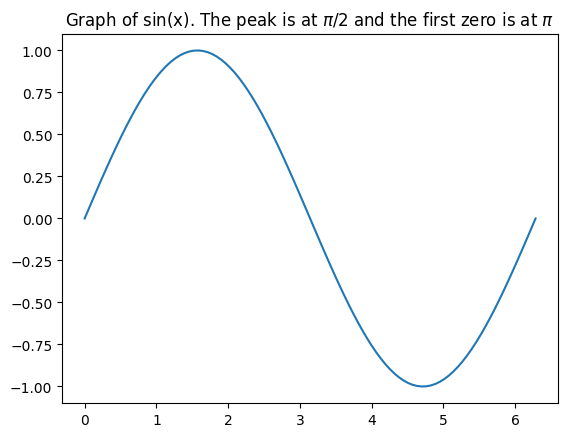

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
x_vals = np.linspace(0,2*np.pi, 100)
sns.lineplot(x=x_vals, y=np.sin(x_vals))
plt.title('Graph of sin(x). The peak is at $\\pi/2$ and the first zero is at $\\pi$')
plt.show()

Here is a python implementation of the above class.

In [28]:
# In python, functions are called 'Callable'.
from collections.abc import Callable

class NotVectorSpace(VectorSpace):
    def __init__(self, func: Callable[[float], float]):
        self.func = func

    def __add__(self, other: NotVectorSpace) -> NotVectorSpace:
        return NotVectorSpace(lambda x:self.func(other.func(x)))

    def __mul__(self, scalar: float) -> NotVectorSpace:
        return NotVectorSpace(lambda x: self.func(x) * scalar)

    def plot(self, title: str) -> None:
        x_vals = np.linspace(-10,10,100) # Just choose 100 points between -2 and 2
        sns.lineplot(x=x_vals, y=self.func(x_vals))
        plt.title(title)
        plt.show()

    def __eq__(self, other: NotVectorSpace) -> bool:
        # It's not really possible to check if two functions are equal, without some
        # symbolic manipulation, so instead just do a 'fuzzy check' by sampling
        # a bunch of equally spaced points between -10 and 10 instead.
        # In particular, this is good enough for polynomials up to degree 999
        x_vals = np.linspace(-10,10,1000)
        return all(self.func(x_vals) == other.func(x_vals))

    def __ne__(self, other: NotVectorSpace) -> bool:
        # Same thing as __eq__ but we check for not equal.
        x_vals = np.linspace(-10,10,1000)
        return all(self.func(x_vals) != other.func(x_vals))

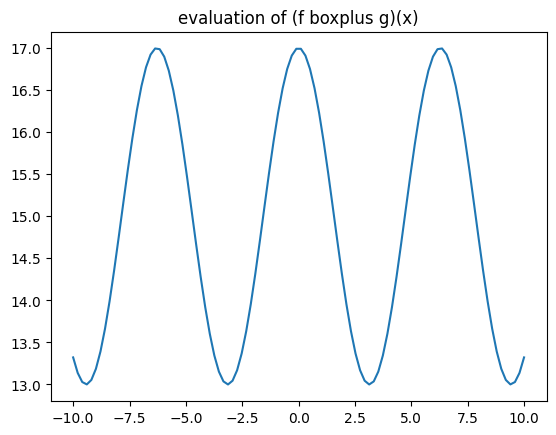

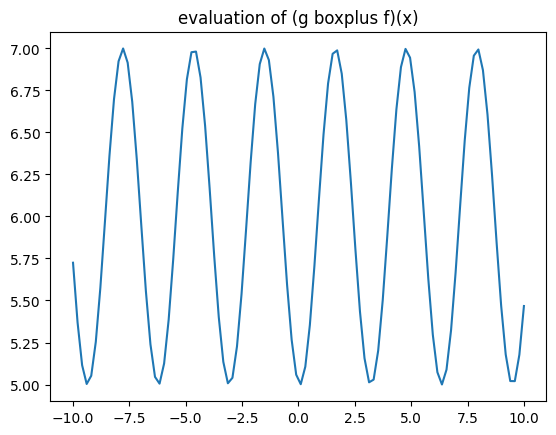

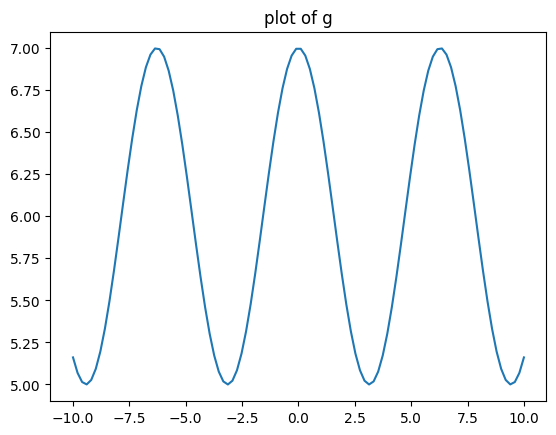

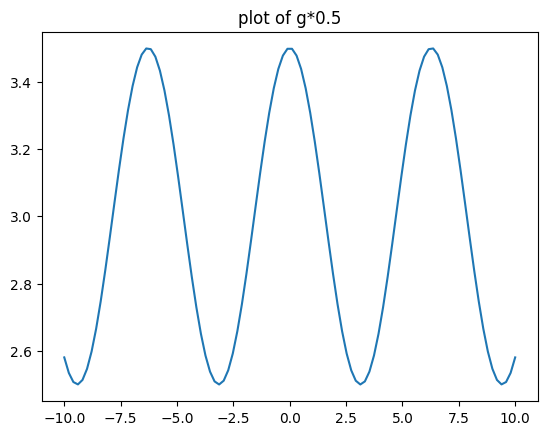

In [29]:
f = NotVectorSpace(lambda x: 3+2*x)
g = NotVectorSpace(lambda x: 6+np.cos(x))
(f+g).plot(title='evaluation of (f boxplus g)(x)')
(g+f).plot(title='evaluation of (g boxplus f)(x)')
g.plot(title='plot of g')
(g*0.5).plot(title='plot of g*0.5')

### Exercise 6
**Functions as a vector space**. Let $X$ be any set (keep in your mind $X = [0,1]$ or $X = \{0,1,2,3\}$). Let $\mathbb{R}^X$ denote the set of functions $f: X \to \mathbb{R}$. So $f$ takes as input elements of $X$, and outputs a real number. Define
- $f\boxplus g$ by $(f\boxplus g)(x) = f(x) + g(x)$.
- $f\cdot\lambda$ as before: $(f\cdot\lambda)(x) = f(x)\cdot\lambda$.

1. **Test that you understand $\boxplus$**: let $f(x) = 1+x^3$ and $g(x) = x^2 + 6$. Find $(f\boxplus g)(1)$.
2. **Test that you understand $\boxplus$**: let $f(x) = x^2$ and $f(x) = \sin(x)$. Find $(f\boxplus g)(\pi/4)$.
3. Find $0$ and find $-f$ and demonstrate as before that $f\boxplus 0 = f$ and $f\boxplus (-f) = 0$.

If $X$ is a finite set of size $d$, there is no mechanical difference between $\mathbb{R}^X$ and the vector space $\mathbb{R}^{d}$ of $d$-tuples (why not?) but we picture them differently. Below are some examples of elements of $\mathbb{R}^{\{0,1,2,3,4,5\}}$.

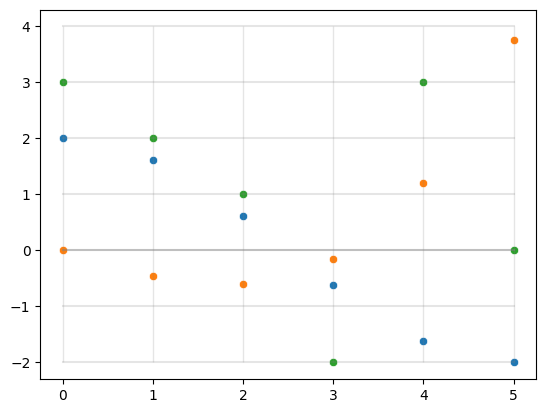

In [30]:
def f(x: int) -> float:
    return 2*np.cos(np.pi*x/5)

def g(x: int) -> float:
    return 0.05*x**3 - 0.5*x

x_vals = np.arange(0,6)

sns.scatterplot(x=x_vals, y=f(x_vals))
sns.scatterplot(x=x_vals, y=g(x_vals))

# Dictionaries are a nice way to code up functions with only finitely many values.
h = {0: 3, 1: 2, 2: 1, 3: -2, 4: 3, 5: 0}
sns.scatterplot(data=h)

for t in np.arange(0,6):
    sns.lineplot(x=[t,t], y=[-2,4], c='gray')
for s in np.arange(-2,5):
    if s != 0:
        sns.lineplot(x=[0,5], y=[s,s], c='gray', alpha=0.2)
    else:
        sns.lineplot(x=[0,5], y=[s,s], c='gray', alpha=0.5)
plt.show()

**Question** Which colours do you think corresponds to f,g, and h? Again, a python implementation of the class $\mathbb{R}^X$, for $X$ a predetermined set.

In [31]:
# I choose $X = {0,1,2,...,5}$ for this example.
X = {0,1,2,3,4,5} # A set is like a list with no ordering, and no repeating elements.

from typing import Dict # provides a dictionary type for python

class FunctionSpace(VectorSpace):
    def __init__(self, func: Dict[..., float]):
        # First we check that the dictionary is providing values in X.
        if set(func.keys()) != X:
            raise ValueError('dictionary must consist of X as keys')

        self.func = func

    def __add__(self, other: FunctionSpace) -> FunctionSpace:
        soln = {x:self.func[x]+other.func[x] for x in X}
        return FunctionSpace(soln)

    def __mul__(self, scalar: float) -> FunctionSpace:
        soln = {x:self.func[x]*scalar for x in X}
        return FunctionSpace(soln)

    def plot(self, title: str) -> None:
        x_vals = sorted(list(X))
        x_min = np.floor(min(x_vals))
        x_max = np.ceil(max(x_vals))
        y_min = np.floor(min([self.func[x] for x in x_vals]))
        y_max = np.ceil(max([self.func[x] for x in x_vals]))

        sns.scatterplot(x=x_vals, y=[self.func[x] for x in x_vals])
        for x in np.arange(x_min,x_max+1):
            sns.lineplot(x=[x, x], y=[y_min,y_max], c='gray')
        for y in np.arange(y_min,y_max+1):
            sns.lineplot(x=[x_min, x_max], y=[y,y], c='gray', alpha=0.2)

        plt.title(title)

    def __str__(self) -> str:
        soln = ''
        for x in X:
            soln += f'f({x}) = {self.func[x]}, '
        return soln[:-2] #print everything but the last comma.

    def __eq__(self, other: FunctionSpace) -> bool:
        return self.func == other.func

    def __ne__(self, other: FunctionSpace) -> bool:
        return not self.__eq__(other)


f(0) = 0.5, f(1) = 1.1116221377419664, f(2) = 0.7012240085521105, f(3) = -0.35387624024035547, f(4) = -1.0836243057397343, f(5) = -0.8170931819315254


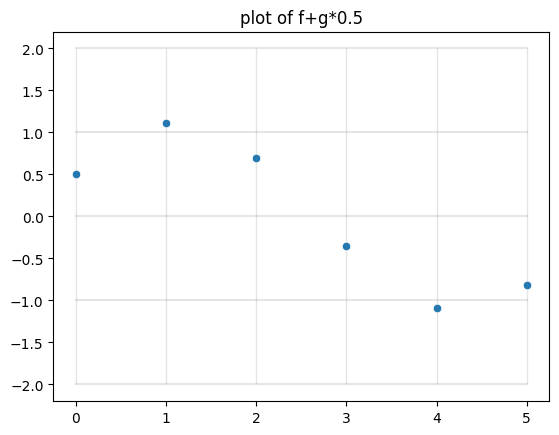

In [32]:
f = FunctionSpace({x:np.sin(x) for x in X})
g = FunctionSpace({x:np.cos(x) for x in X})
print(f+g*0.5)
(f+g*0.5).plot(title='plot of f+g*0.5')

### Exercise 7
**Polynomials with imposed conditions** We introduce a further condition to polynomials: we let $P_3(x,\mathbb{R}; x^2 - 2)$ denote the cubic functions $f(x) = a + bx + cx^2 + dx^3$ with the additional condition that $x^2 - 2 = 0$. This means that $f(x)$ can be rewritten as
$$
    f(x) = a + bx + c \cdot 2 + d\cdot(2 \cdot x) = (a + 2c) + (b + 2d)x \;.
$$
The operations $\cdot$ and $\boxplus$ are the same as in the usual operations for polynomials.

Notice that now it does *not* make sense to take $f(1)$ (since $x^2 - 2 = 0$ imposes $x = \sqrt{2}$ or $x=-\sqrt{2}$). This demonstrates a subtle difference between the way we think about polynomials vs the way we think about functions: functions can always be evaluated at every input point, but sometimes it doesn't make sense to evaluate polynomials.

1. Let $f(x) = 1+x^3$ and $g(x) = x^2 + 6$ find a linear polynomial $h(x) = a+bx$ so that $f(x)\boxplus g(x) = h(x)$.
2. Show that if $f(x) = 1+6x^3$ then $g(x) = -1 - 12x$ and $h(x) = -1 - 6 x^3$ both work for $-f(x)$. Why does this *not* contradict the uniqueness of an inverse?

In [33]:
# Class Cubic of cubics with the additional imposed condition x^2-2 = 0.
class Cubic(VectorSpace):
    def __init__(self, constant: float = 0, linear:float = 0, quadratic:float = 0, cubic:float = 0):
        self.constant = constant
        self.linear = linear
        self.quadratic = quadratic
        self.cubic = cubic

    def reduce(self, inplace: bool = False) -> Quad:
        """
            Reduces a polynomial to is linear form.
            Args:
                inplace: Default: False. If True, the polynomial is modified in-place.
            Returns:
                Quad object in linear form.
        """
        if inplace:
            self.constant += 2*self.quadratic
            self.linear += 2*self.cubic
            self.quadratic = 0
            self.cubic = 0
            return self
        else:
            new = Quad()
            new.constant = self.constant + 2*self.quadratic
            new.linear = self.linear + 2*self.cubic
            return new


    def __add__(self, other: Quad) -> Quad:
        new = Quad()
        new.constant = self.constant + other.constant
        new.linear = self.linear + other.linear
        new.quadratic = self.quadratic + other.quadratic
        new.cubic = self.cubic + other.cubic
        new.reduce()
        return new

    # This is to scalar multiply a vector.
    def __mul__(self, scalar: float) -> Quad:
        new = Quad()
        new.constant = self.constant*scalar
        new.linear = self.linear*scalar
        new.quadratic = self.quadratic*scalar
        new.cubic = self.cubic*scalar
        new.reduce()
        return new

    def __eq__(self, other) -> bool:
        a = self.reduce()
        b = other.reduce()
        return a.constant == b.constant and a.linear == b.linear

    def __ne__(self, other) -> bool:
        return not self.__eq__(other)

    # This makes sure that printing the quadratics looks the way we expect
    def __str__(self):
        return f'{self.constant}+{self.linear}x+{self.quadratic}x^2+{self.cubic}x^3'

### Exercise 8
This next vector space will be very important throughout our work. We extend the polynomial example from before with a polynomial with no roots. Consider the vector space $P_2(x,\mathbb{R};x^2+1)$. These are the quadratics $f(x) = a+bx+cx^2$ with the additional condition that $x^2+1 = 0$. This means that
$$
    f(x) = a+bx+cx^2 = a+bx +c(-1) = (a-c)+bx\;.
$$
Since for every real number $a$, $a^2 + 1 \geq 1$, we know that there is no real number representative for $x$.

1. Show that it is not possible to reduce $f(x) = 1+2x$ to a constant $g(x) = a$. That is, there is no number $a$ so that $f(x) = a$. Hint: suppose that there *is* such a number $a$. What would that imply about the value of $x$?
2. Write down a quadratic $zero(x) = a+bx+cx^2$ with $c \neq 0$ so that $f(x)+zero(x) = f(x)$ for any quadratic $f(x)$ in this space.

Below we code up a python class that let us evaluate sums and scalar products of polynomials from this vector space.

In [34]:
# Class Quad of quadratics with the additional imposed condition x^2+1 = 0.
class Quad(VectorSpace):
    def __init__(self, constant: float = 0, linear:float = 0, quadratic:float = 0):
        self.constant = constant
        self.linear = linear
        self.quadratic = quadratic

    def reduce(self, inplace: bool = False) -> Quad:
        """
            Reduces a polynomial to is linear form.
            Args:
                inplace: Default: False. If True, the polynomial is modified in-place.
            Returns:
                Quad object in linear form.
        """
        if inplace:
            self.constant += -self.quadratic
            self.quadratic = 0
            return self
        else:
            new = Quad()
            new.constant = self.constant - self.quadratic
            new.linear = self.linear
            return new

    def __add__(self, other: Quad) -> Quad:
        new = Quad()
        new.constant = self.constant + other.constant
        new.linear = self.linear + other.linear
        new.quadratic = self.quadratic + other.quadratic
        new.reduce()
        return new
    
    # This is to scalar multiply a vector. 
    def __mul__(self, scalar: float) -> Quad:
        new = Quad()
        new.constant = self.constant*scalar
        new.linear = self.linear*scalar
        new.quadratic = self.quadratic*scalar
        new.reduce()
        return new

    def __eq__(self, other) -> bool:
        a = self.reduce()
        b = other.reduce()
        return a.constant == b.constant and a.linear == b.linear

    def __ne__(self, other) -> bool:
        return not self.__eq__(other)

    # This makes sure that printing the quadratics looks the way we expect
    def __str__(self):
        return f'{self.constant}+{self.linear}x+{self.quadratic}x^2'

In [35]:
a = Quad(constant=1, quadratic=6)
b = Quad(constant=2, linear=1)
print(f'{a} + {b} = {a+b}')

1+0x+6x^2 + 2+1x+0x^2 = 3+1x+6x^2


In [36]:
print(f'({a})*3 = {a*3}')

(1+0x+6x^2)*3 = 3+0x+18x^2


In [37]:
# Check that x^2 is equal to -1 in this scenario.
a = Quad(quadratic=1)
b = Quad(constant=-1)
print(a == b)

True


## A taste of what's to come: dual vector spaces
A really important construction for vector spaces is known as the 'dual vector space'. Given a vector space $V$, the dual space $V^*$ is a new vector space where its objects consist of functions $f: V \to \mathbb{R}$ with the property that
- $f(v+w) = f(v)+f(w)$ for any $v,w \in V$ and
- $f(v\cdot \lambda) =f(v)\cdot \lambda$.

That is, $V^*$ is a *subclass* of $\mathbb{R}^V$. The operations $+$ and $\cdot$ are exactly the same as in $\mathbb{R}^V$: given $f,g \in V^*$, $\lambda$ a scalar, and $v \in V$,
- $(f+g)(v) = f(v)+g(v)$
- $(f \cdot \lambda)(v) = f(v)\cdot \lambda$

Immediately, there is a question you must ask yourself: we know that $f,g \in V^*$, but must $f+g$ and $f \cdot \lambda$ also be in $V^*$? That is, are $f+g$ and $f \cdot \lambda$ *also* dual vectors?

**Theorem**: The dual vector space $V^*$ is *closed under* $+$ and $\cdot$. That is, if $f,g \in V^*$ and $\lambda$ is a scalar, then $f+g \in V^*$ and $f \cdot \lambda \in V^*$.

**Proof**: The proof is pretty simple, and I want to make it into a guided exercise. Assuming that $f$ and $g$ are dual vectors, our first goal is to show that $f+g$ is a dual vector.
1. Let $v,w \in V$. Show that $(f+g)(v+w) = (f+g)(v) + (f+g)(w)$.
- Hint 1: The symbol $+$ is *very* overloaded here! In fact, there are *three different* ues of $+$ here. Can you identify them all?
- Hint 2: you need to reduce both the left and right hand side until it's a sum of four numbers.
2. Let $\mu$ be a scalar. Show that $(f+g)(v \cdot \mu) = (f+g)(v) \cdot \mu$.
- Hint 1: Again, $\cdot$ is overloaded here. What is the difference between the two uses of $\cdot$?
- Hint 2: we again need to reduce both sides until it's a sum of two numbers.

Next we need to show that $f \cdot \lambda$ is a dual vector if $f$ is a dual vector and $\lambda$ is a scalar.

3. Let $v,w \in V$. Show that $(f \cdot \lambda)(v+w) = (f \cdot \lambda)(v) + (f \cdot \lambda)(w)$.
4. Let $v \in V$ and $\mu$ be a scalar. Show that $(f \cdot \lambda)(v \cdot \mu) = (f\cdot \lambda)(v)\cdot \mu$.

**Sanity check**: What should the zero vector of $V^*$ be? Hint: it has to be a function $\text{zero}: V \to \mathbb{R}$. What is $\text{zero}(v)$?

**Important**: The class $V^*$ is *more* than just a vector space, because it has one extra method: given $f \in V^*$ and $v \in V$, there is an operation $(f,v) \mapsto f(v)$.

It can be quite difficult to figure out a good way to implement $V^*$ in general, and part of the difficulty is that an implementation of $V^*$ should also include a function that lets us take $f \in V^*$ and $v \in V$ and evaluate $f(v)$. Variations of such a problem can be objectively very difficult (on the level of serious research). Luckily, for the examples that we will concern ourselves with, it will be easy to know an ad hoc way to implement $V^*$.

### Exercise 10
In this exercise, we try to work out $\mathbb{R}^*$, the dual space of the vector space $\mathbb{R}$ of real numbers. Remember, $\mathbb{R}^*$ consists of functions $f: \mathbb{R} \to \mathbb{R}$ for which
- $f(x+y) = f(x)+f(y)$ for $x,y \in \mathbb{R}$, and
- $f(x\cdot\lambda) = f(x)\cdot \lambda$ for $x \in \mathbb{R}$ and $\lambda$ scalar.

1. Show that if $f \in \mathbb{R}^*$, then there is a number $a_f$ such that $f(x)= a_f \cdot x$ for all $x \in \mathbb{R}$. That is, $f$ is determined entirely by $a_f$.
2. Show that if $f, g \in \mathbb{R}^*$ then $(f+g)(x) = (a_f+a_g)\cdot x$. Conclude that $a_{f+g} = a_f + a_g$.
3. Show that if $f \in \mathbb{R}^*$ and $\lambda$ is a scalar, then $(f \cdot \lambda)(x) = (a_f \cdot \lambda)\cdot x$. That is $a_{f\cdot\lambda} = a_f \cdot \lambda$.

An implementation of $\mathbb{R}^*$ is given below. Note that because the dual space is completely determined by a single number, and because the number behaves the way we expect with respect to $+$ and $\cdot$ (questions 2 and 3 above), we can always inherit the operations from the class 'RealNumbers'.

In [38]:
class DualRealNumber(RealNumber):
    def eval(self, vector: RealNumber) -> float:
        return self.value*vector.value

    def __str__(self) -> str:
        #We print it like a function
        return f'x -> {self.value}*x'

In [39]:
f = DualRealNumber(2)
print(f'f = {f}')
x = RealNumber(4)
print(f'x = {x}')
print(f'f({x}) = {f.eval(x)}')

f = x -> 2*x
x = 4
f(4) = 8


### Exercise 11
Next we'll consider $(\mathbb{R}^2)^*$, the dual space of the vector space of pairs $(a,b)$ ($a,b \in \mathbb{R}$). Functions $f \in (\mathbb{R}^2)^*$ are such that:
- $f((a,b)+(c,d)) = f(a,b) + f(c,d)$
- $f((a,b)\cdot \lambda) = f(a,b)\cdot \lambda$

for any numbers $a,b,c,d,\lambda$.

1. Show that if $f \in (\mathbb{R}^2)^*$ then there are two numbers $a_f, b_f \in \mathbb{R}$ such that $f(x,y) = a_f\cdot x + b_f \cdot y$. Hint: choose a good $x,y$ to find $a_f$ and $b_f$.
2. Show that if $f,g \in (\mathbb{R}^2)^*$ then $(f+g)(x,y) = (a_f + a_g)\cdot x + (b_f + b_g)\cdot y$. That is, $a_f + a_g = a_{f+g}$ and $b_f + b_g = b_{f+g}$.
3. Show that if $f \in (\mathbb{R}^2)^*$ and $\lambda$ is a scalar then $(f \cdot \lambda)(x,y) = (a_f \cdot \lambda)\cdot x + (b_f \cdot \lambda)\cdot y$. That is, $a_{f \cdot \lambda} = a_f \cdot \lambda$ and $b_{f \cdot \lambda} = b_f \cdot \lambda$.

Again, this analysis tells us that we can make the class $(\mathbb{R}^2)^*$ by inheriting from the 'Pair' class.

In [40]:
class DualPair(Pair):
    def eval(self, vector: Pair) -> float:
        return self.left*vector.left + self.right*vector.right

    def __str__(self) -> str:
        return f'(x,y) -> {self.left}x + {self.right}x'

In [41]:
f = DualPair(2,4)
print(f'f = {f}')
x = Pair(-1,1)
print(f'x = {x}')
print(f'f({x}) = {f.eval(x)}')

f = (x,y) -> 2x + 4x
x = (-1,1)
f((-1,1)) = 2


## Dirac's bra and ket spaces
As mentioned previously, the fact that $V^*$ uses operations from $V$ mean that it gets a special operation:
$$
    \langle \cdot | \cdot \rangle: V^* \times V \to \mathbb{R} : \langle f | v \rangle = f(v) \;.
$$

We've exclusively focused on the fact that $\langle f | \cdot \rangle$ is a linear function, but notice we could fix $v \in V$ and instead look at the function
$$
    \langle \cdot | v \rangle : V^* \to \mathbb{R} : f \mapsto f(v) \;.
$$
This function has two important properties:
1. $\langle f + g | v \rangle = \langle f | v \rangle + \langle g | v \rangle$ for any $f,g \in V^*$.
2. $\langle f \cdot \lambda |v \rangle = \langle f | v \rangle \cdot \lambda$ for any $f \in V^*$ and $\lambda$ scalar.

In other words, the function $\langle \cdot | v \rangle$ is *also a dual vector*. That is, $\langle \cdot | v \rangle \in (V^*)^*$.

It was Paul Dirac who observed that given a vector space $V$, we then have two 'dual' classes.
1. We have $|V\rangle$, the 'ket space' of $V$, which is $V$ as a vector space, and $\langle V|$, the 'bra space' of $V$, which is $V^*$ as a vector space.
2. The ket space $|V \rangle$ comes with it an additional method
$$
    eval: |V \rangle \times \langle V| \to \mathbb{R} : (v, f) \mapsto f(v) \;.
$$
3. Similarly, the bra space $\langle V|$ comes with it an additional method
$$
    eval: \langle V| \times |V \rangle \to \mathbb{R} : (f,v) \mapsto f(v) \;.
$$

For example, I give the bra-ket implementation for the space $\mathbb{R}^2$. For us, this will be the most important bra and ket spaces.

In [42]:
class PairKet(Pair):
    def eval(self, vector: PairBra) -> float:
        return self.left*vector.left + self.right*vector.right

    def __str__(self) -> str:
        return f'|({self.left},{self.right})>'

# Note! The Bra class is identical to the DualPair class (as it should be)
# with the only exception being how we print our function.
class PairBra(Pair):
    def eval(self, vector: PairKet) -> float:
        return self.left*vector.left + self.right*vector.right

    def __str__(self) -> str:
        return f'<({self.left},{self.right})|'

In [43]:
v = PairKet(1,2)
print(f'v = {v}')
f = PairBra(2,3)
print(f'f = {f}')
print(f'<f|v> = {f.eval(v)}')

v = |(1,2)>
f = <(2,3)|
<f|v> = 8


As alluded to in the implementation, given a vector $v \in V$, its associated ket is denoted $|v \rangle$ and given a dual vector $f \in V^*$, its associated bra is $\langle f|$. The evaluation fuction is then denoted by the bra-ket $\langle f| v \rangle$. At the moment, this is just Dirac's notational whimsy, but we shall see that the bra-ket notation is very powerful indeed.

### Exercise 12
In this exercise we explore different ways of representing an element in the bra space. Let $f \in (\mathbb{R}^2)^*$ and let $\langle f|$ be the associated bra vector.
1. Let $|0\rangle$ be the ket associated to the pair $(1,0)$ and $|1 \rangle$ be the ket associated to the pair $(0,1)$. We let $\langle 0 |, \langle 1|$ be the associated bra vectors, that is, $\langle 0|, \langle 1|$ are dual vectors that satisfy the identity
$$
    \langle 0 | (a,b) \rangle = a \text{ and } \langle 1 | (a,b) \rangle = b
$$
for $a,b \in \mathbb{R}$.
- Show that any ket $|v \rangle \in |\mathbb{R}^2 \rangle$ satisfies the identity
$$
    | v \rangle = | 0 \rangle \langle 0 | v \rangle + |1 \rangle \langle 1 | v \rangle \;.
$$
- Show that for any $|v\rangle \in |\mathbb{R}^2 \rangle$,
$$
    \langle f| v \rangle = \langle f | 0 \rangle \langle 0 | v \rangle + \langle f | 1 \rangle \langle 1 | v\rangle \;.
$$
- Show that $\langle 0 | 0 \rangle = 1$, $\langle 0 | 1 \rangle = 0$, $\langle 1 | 0 \rangle = 0$, and $\langle 1 | 1 \rangle = 1$.
2. Let $|+ \rangle$ be the ket associated to the vector $(1,1)\cdot \frac{1}{\sqrt{2}}$ and let $|- \rangle$ be the ket associated to the vector $(1,-1)\cdot \frac{1}{\sqrt{2}}$. Let $\langle +|, \langle - |$ be the associated bra vectors. That is,
$$
    \langle + | (a,b) \rangle = \frac{1}{\sqrt{2}}a + \frac{1}{\sqrt{2}}b \text{ and } \langle - | (a,b) \rangle = \frac{1}{\sqrt{2}}a - \frac{1}{\sqrt{2}}b \;.
$$
- Show that any ket $|v \rangle$ satisfies the identity
$$
    | v \rangle = | + \rangle \langle + | v \rangle + |- \rangle \langle - | v \rangle \;.
$$
- Show that for any $|v\rangle \in |\mathbb{R}^2 \rangle$,
$$
    \langle f| v \rangle = \langle f | + \rangle \langle + | v \rangle + \langle f | - \rangle \langle - | v\rangle \;.
$$
- Show that $\langle + | + \rangle = 1$, $\langle + | - \rangle = 0$, $\langle - | + \rangle = 0$, and $\langle - | - \rangle = 1$.
3. Find an example of $|v \rangle \in |\mathbb{R}^2 \rangle$ such that
$$
    | v \rangle \neq | 0 \rangle \langle 0 | v \rangle + | + \rangle \langle + | v \rangle \;.
$$

We say that the collection $|\phi \rangle, |\psi \rangle$ is an **orthonormal basis** if
$$
    \langle \phi | \phi \rangle = 1 , \langle \psi | \psi \rangle = 1, \langle \psi | \phi \rangle = 0, \langle \phi | \psi \rangle = 0\;.
$$

4. Show that if $|\phi \rangle, |\psi \rangle$ is an orthonormal basis then for any vector $|v \rangle$,
$$
    |v \rangle = |\phi \rangle \langle \phi| v \rangle + |\psi \rangle \langle \psi | v \rangle \;.
$$

### Exercise 13
Let $X$ be a finite set. For example, $X = \{0,1,2,3\}$. In this exercise, we explore the bra and ket space of $\mathbb{R}^X$. For each $x \in X$, let $|x \rangle$ be the ket corresponding to the function
$$
    |x \rangle : X \to \mathbb{R}: y \mapsto \begin{cases}1 &\text{ if }x = y \\ 0 &\text{ if }x \neq y \end{cases} \;.
$$
As well, define the bra vector
$$
    \langle x | : \mathbb{R}^X \to \mathbb{R} : \langle x |(f) = f(x) \;.
$$

1. Show that $\langle x |$ is indeed a dual vector. That is, show that for any $f,g\in \mathbb{R}^X$, we have
$$
    \langle x| (f+g) = \langle x|(f) + \langle x|(g)
$$
and
$$
    \langle x|(f \cdot \lambda) = \langle x|(f) \cdot \lambda \;.
$$
2. Let $X = \{0,1,2,3\}$. Show that for any $f \in \mathbb{R}^X$, we have the identity
$$
    |f \rangle = |0 \rangle \langle 0 | f \rangle + |1 \rangle \langle 1 | f \rangle + |2 \rangle \langle 2 | f \rangle + |3 \rangle \langle 3 | f \rangle\;.
$$
Hint: This question has a lot of parts. First figure out what $\langle 0 | f \rangle$ means, then try to find $|f \rangle (x)$ for each $x$.


Later on, we'll see a recipe for extracting a bra $\langle \psi |$ for every ket $| \psi \rangle$.

# Homework

## Warmup exercises
These exercises are intended to prepare you for the exercises below. Often these will focus on elementary concepts in mathematics. These should be done before attempting the homework exercises. The solutions are provided at the end of this notebook. Do not read the solutions unless you feel absolutely stuck.
### Warmup Exercise 1
Recall that for a quadratic polynomial $p(x) = ax^2 + bx +c$ (with $a \neq 0$), we have the roots

$$
    x_{\pm} = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} \;.
$$

That is, $x_{\pm}$ are the two points where $p(x_\pm) = 0$. Note that if $p(x)$ *has* two roots $x_\pm$, then $p(x) = a\cdot(x-x_+)\cdot(x-x_-)$.
For example, consider the polynomial $p_0(x) = 3x^2 - 9x + 4$. In this case, $a=3$, $b=-9$, and $c = 4$. Therefore, by the formula, the roots are

$$
    x_{\pm} = \frac{-(-9) \pm \sqrt{(-9)^2 - 4 \cdot 3 \cdot 4}}{2 \cdot 3} = \frac{9 \pm \sqrt{81 - 48}}{6} = \frac{9 \pm \sqrt{33}}{6} \;.
$$
That is, the two roots are $x_+ = \frac{9 + \sqrt{33}}{6}$ and $x_- = \frac{9 - \sqrt{33}}{6}$. We can check that we have the correct solution by expanding the equation $a \cdot (x - x_+) \cdot (x- x_-)$:
$$
\begin{align*}
    a \cdot (x - x_+) \cdot (x - x_-) &= 3 \cdot \left( x - \frac{9 + \sqrt{33}}{6} \right) \cdot \left(x - \frac{9 - \sqrt{33}}{6} \right) \\
    &= 3 \cdot \left(x^2 - \frac{9 + \sqrt{33}}{6} x - \frac{9 - \sqrt{33}}{6}x + \frac{9 + \sqrt{33}}{6}\cdot\frac{9 - \sqrt{33}}{6} \right) \\
    &= 3 \cdot \left(x^2 - \frac{9}{3}x + \frac{9 + \sqrt{33}}{6}\cdot\frac{9 - \sqrt{33}}{6} \right)
\end{align*}
$$
where in the last line I used the fact that the terms $-\frac{\sqrt{33}}{6}x$ and $\frac{\sqrt{33}}{6}x$ cancel out. Finally, to deal with the constant term, recall that when you have two numbers $s,t$, we have the identity $s^2 - t^2 = (s+t)(s-t)$. In this case, since
$$
\frac{9 + \sqrt{33}}{6}\cdot\frac{9 - \sqrt{33}}{6} = \frac{(9 + \sqrt{33})(9 -\sqrt{33})}{6^2}\;,
$$
setting $s = 9$ and $t = \sqrt{33}$, we see that
$$
\frac{9 + \sqrt{33}}{6}\cdot\frac{9 - \sqrt{33}}{6} = \frac{9^2 - \sqrt{33}^2}{6^2} = \frac{81 - 33}{36} = \frac{48}{36} \;.
$$
Putting everything together, we get
$$
a \cdot (x - x_+) \cdot (x - x_-) = 3 \cdot \left( x^2 - \frac{9}{3}x + \frac{48}{36}\right) = 3x^2 - 9x + \frac{48}{12} = 3x^2 - 9x + 4 = p_0(x)
$$
as we expected.

Find the roots (points where $p(x) = 0$) of the following quadratic polynomials. Verify by expansion that $p(x) = a\cdot(x-x_+)(x-x_-)$.
1. $p_1(x) = x^2 - 2x + 1$
2. $p_2(x) = x^2 + 2x + 1$
3. $p_3(x) = 2x^2 + 3x - 1$
4. $p_4(x) = x^2 + 5x - 4$

### Warmup Exercise 2
Recall in particular that $p(x)$ does not have a *real* root if and only if the discriminant
$$
    \Delta(p) = b^2 - 4ac
$$
is negative (since we cannot take the square root of a negative number). In other words, if $\Delta(p) < 0$, then $p(x)$ has no real roots, and if $\Delta(p) \geq 0$, then $p(x)$ has real roots.

For example, consider the polynomial $p_0(x) = x^2 + 1$. Since $a =1$, $b=0$, and $c=1$, its discriminant is $\Delta(p_0) = (0)^2 - 4 \cdot 1 \cdot 1 = - 4 < 0$. Therefore, $p_0(x)$ has no real roots. This makes sense since $x^2 \geq 0$ for any $x$, so $x^2 + 1 \geq 1$ always.

For the following polynomials, verify whether it has real roots or not using the discriminant (do *not* calculate the roots).
1. $p_1(x) = x^2 +3 x + 9$
2. $p_2(x) = x^2 - 3x + 9$
3. $p_3(x) = 2x^2 + 14x + 56$
4. $p_4(x) = x^2 + 8x - 2$

If $a > 0$ and $c < 0$, why does $p(x) = ax^2 + bx + c$ always have real roots?

### Warmup Exercise 3
In this exercise, we give an exact description of the cosine and sine functions: these are a pair of functions $(\cos(t),\sin(t))$ which describe points on a circle of unit radius. That is, 
- for every pair $(x,y) \in \mathbb{R}^2$ of unit length: $x^2 + y^2 = 1$, there is a number $t$ so that $(x,y) = (\cos(t),\sin(t))$. 
- Conversely, every number $t$ assigns a point on the circle: $\cos(t)^2 + \sin(t)^2 = 1$. 

**Sanity check**: make sure you understand why these two things are saying different things. What could go wrong if only one of the two conditions hold but the other one fails?

These two properties are not enough to tell us how to calculate $\cos(t)$ or $\sin(t)$ for any $t$, but in this exercise we go through important identities that will tell us exactly how to calculate $\cos(t)$ and $\sin(t)$.

This initial property is just to make sure $\cos(t)$ and $\sin(t)$ behaves the way you expect it to, and we will not use it for any calculations. 

0. The functions $\cos(t)$ and $\sin(t)$ are **continuous**. This means that if you had a sequence $t_1,t_2,t_3,\ldots$ of approximations of a number $t$, then $\cos(t)$ and $\sin(t)$ can be approximated as close as you want using $t_1,t_2,\ldots$. For example, if you knew all the decimal points of $\sqrt{2} \simeq 1.4142135637\ldots$ (or you had a formula for $\sqrt{2}$), you can write the decimal approximation by 
$$
    t_1 = 1.4, t_2 = 1.41, t_3 = 1.414, t_4 = 1.4142, t_5 = 1.41421, \ldots, t_n = 1.(\text{first n digits of }\sqrt{2})
$$
then $\cos(\sqrt{2})$ will be better and better approximated by $\cos(t_1), \cos(t_2), \cos(t_3),\ldots$ in the sense that, if you wanted to know the first $8$ decimal points of $\cos(\sqrt{2})$ exactly, I know that I can choose some large enough $n$ so that $\cos(t_n)$ gives us the first $8$ decimal points.

The remaining properties tell you how to calculate $\cos(t)$ and $\sin(t)$ for important values. 

1. $\cos(0) = 1$, $\sin(0) = 0$, and $\sin(t)^2+\cos(t)^2=1$ for all $t$.
2. There is a point $t_0 > 0$ so that $\cos(t_0) = 0$ and so that $\cos(t) > 0$ if $0 < t < t_0$. So, the point $t_0$ can be thought of as the *first point* after $0$ where $\cos(t_0) =0$. The number $\pi$ is defined to be $2 \cdot t_0$. In other words, 
$$
    \cos\left(\frac{\pi}{2}\right) = 0 \;.
$$
I want to reiterate that this is the **definition** of $\pi$, and not some derived relation about a number to cosine.

3. For any $t$ such that  $0 < t \leq \pi/2$, $\sin(t) > 0$. This condition is asserting that $(\cos(t),\sin(t))$ is rotating *counterclockwise* as $t$ goes up.  

4. We have the sum of angles theorem: for any $\alpha, \beta \in \mathbb{R}$, 
$$
\begin{align*}
    \cos(\alpha + \beta) &= \cos(\alpha)\cos(\beta) - \sin(\alpha)\sin(\beta) \\
    \sin(\alpha + \beta) &= \sin(\alpha)\cos(\beta) + \cos(\alpha)\sin(\beta) \;. 
\end{align*}
$$

In this exercise, we are going to work out all of the properties of sine and cosine that you might be familiar with using only the rules 1,2,3, and 4. 

1. Show that $\sin\left(\frac{\pi}{2} \right) = 1$. Hint: one part of the problem uses the identity $\cos(t)^2 + \sin(t)^2 = 1$. 
2. Show that $\cos(\alpha + \pi/2) = - \sin(\alpha)$ and $\sin(\alpha + \pi/2) = \cos(\alpha)$ for all numbers $\alpha$.
3. Use the previous exercise to show that 
- $\cos(\alpha + \pi) = -\cos(\alpha)$, 
- $\sin(\alpha + \pi) = - \sin(\alpha)$, 
- $\cos(\alpha + 2\pi) = \cos(\alpha)$, and 
- $\sin(\alpha+ 2\pi) = \sin(\alpha)$ 

for all $\alpha$. This establishes the 'periodicity' of cosines and sines. 

4. Our goal is to show that $\sin(-\alpha) = -\sin(\alpha)$ and $\cos(-\alpha) = \cos(\alpha)$ for all numbers $\alpha$. We do this in the following steps:
- Using the sum of angles identity, establish the relations 
$$
\begin{align*}
    1 &= \cos(\alpha)\cos(-\alpha) - \sin(\alpha)\sin(-\alpha) \\
    0 &= \sin(\alpha)\cos(-\alpha) + \cos(\alpha)\sin(-\alpha) \;. 
\end{align*}
$$
Let $f(\alpha) = \cos(\alpha)\cos(-\alpha) - \sin(\alpha)\sin(-\alpha)$ and let $g(\alpha) = \sin(\alpha)\cos(-\alpha) + \cos(\alpha)\sin(-\alpha)$. Note that for all $\alpha$, $f(\alpha) = 1$ and $g(\alpha) = 0$. 
- By calculating $\cos(\alpha)f(\alpha) + \sin(\alpha)g(\alpha)$, show that $\cos(-\alpha) = \cos(\alpha)$. 
- By calculating $-\sin(\alpha)f(\alpha) + \cos(\alpha)g(\alpha)$, show that $\sin(-\alpha) = -\sin(\alpha)$. 

This bit of 'magic' will become clearer to us when we revisit matrices. 

5. Establish the identity $\cos\left(\frac{\pi}{4}\right) = \frac{1}{\sqrt{2}}$ and the identity $\sin\left(\frac{\pi}{4}\right) = \frac{1}{\sqrt{2}}$.

Below we plot $\cos\left(\frac{\pi}{2} \cdot \alpha\right)$ and $\sin\left(\frac{\pi}{2} \cdot\alpha\right)$ for $\alpha \in [-8,8]$ (corresponding to four rotations on the circle). Notice the direction of rotation forced by the fact that $\sin(\alpha) >0$ when $\alpha \in (0,\pi)$.

In [44]:
from ipywidgets import interact, FloatSlider
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
alpha = FloatSlider(value=0.2,
                    min=-8,
                    max=8,
                    step=0.1,
                    disabled=False,
                    continuous_update=False,
                    orientation='horizontal',
                    readout=True,
                    readout_format='.1f')


def plot_circle(alpha):
    plt.figure(figsize=(5,5))
    sns.lineplot(x = [0, np.cos(np.pi*alpha/2)], y= [0, np.sin(np.pi*alpha/2)], c='black')
    sns.lineplot(x = np.cos(np.linspace(0, np.pi, 100)), y=np.sin(np.linspace(0, np.pi, 100)), c='gray')
    sns.lineplot(x = np.cos(np.linspace(-np.pi, 0, 100)), y=np.sin(np.linspace(-np.pi, 0, 100)), c='gray')
    sns.lineplot(x=[0,np.cos(np.pi*alpha/2)], y=[0,0], c='blue', alpha=0.5)
    sns.lineplot(x=[0,0], y=[0,np.sin(np.pi*alpha/2)], estimator=None, c='orange', alpha=0.5)
    sns.lineplot(x=[-1,1], y=[0,0], c='gray', estimator=None, alpha=0.2)
    sns.lineplot(x=[0,0], y=[-1,1], c='gray', estimator=None, alpha=0.2)

    plt.show()

interact(plot_circle, alpha = alpha);

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='alpha', max=8.0, min=-8.0, …

Fig: Plot of $(\cos\left(\frac{\pi}{2}\cdot \alpha\right), \sin\left(\frac{\pi}{2}\cdot\alpha\right))$ (black). The blue and orange lines represent $\cos\left(\frac{\pi}{2}\cdot \alpha\right)$ and $\sin\left(\frac{\pi}{2}\cdot\alpha\right)$ respectively.

### Remark on multiples of $\pi$ vs the convention of degrees

You might wonder why multiples of $\pi$ (sometimes referred to as *radians*) is preferred over the more conventional *degrees*. The reason has to do with the *velocity* of the system. Suppose that a particle traces a path $x(t) = (\cos(t),\sin(t))$ at time $t$. What is the velocity of this particle? Some standard calculus tells us that
$$
    v(t) = x'(t) = \left(\cos'(t), \sin'(t)\right) = (-\sin(t),\cos(t)) \;,
$$
and so its speed is given by the length of this vector: $\|v(t)\| = \sqrt{(-\sin(t))^2 + \cos(t)^2} = \sqrt{1} = 1$. In this sense, it is very simplistic to take this as the *natral units* of this system.

On the other hand, if we do the unit conversion, say $x_{deg}(t) = (\cos(\frac{\pi}{180} t), \sin(\frac{\pi}{180} t))$, then we find that its speed is $\|v_{deg}(t)\| = \frac{\pi}{180}$, a most arbitrary speed indeed. This means that

- Radians make more sense to work with in theory, since properties like the speed is nice and clean.
- Degrees are better in practice, since the corresponding values of sine and cosine come from integers.

### Remark on the existence of a *first point of zero*

One of the basic properties of cosine is that there is a first point $t_0$ after $0$ where $\cos(t_0) = 0$. You might think that any function $f(t)$ that starts at $f(0) = 1$, and later goes down to $f(t) = -1$ must have such a *first zero*. Even if the function is *nice* (in the sense of 'continuous' and has positive points where it is zero), such a *first* point does not need to exist. For example, consider the following function:
$$
    f(t) = \begin{cases} t\cdot \sin\left(\frac{\pi}{t}\right) &t \neq 0 \\ 0 & t=0 \end{cases}
$$
Notice that at points $1, \frac{1}{2}, \frac{1}{3},\frac{1}{4},\ldots, \frac{1}{n},\ldots$, $f\left(\frac{1}{n}\right) = \frac{1}{n}\sin(\pi \cdot n) = 0$. Therefore, there is no *first* positive point $t_0 > 0$ where $f(t_0) =0$. A plot of this function is given below:

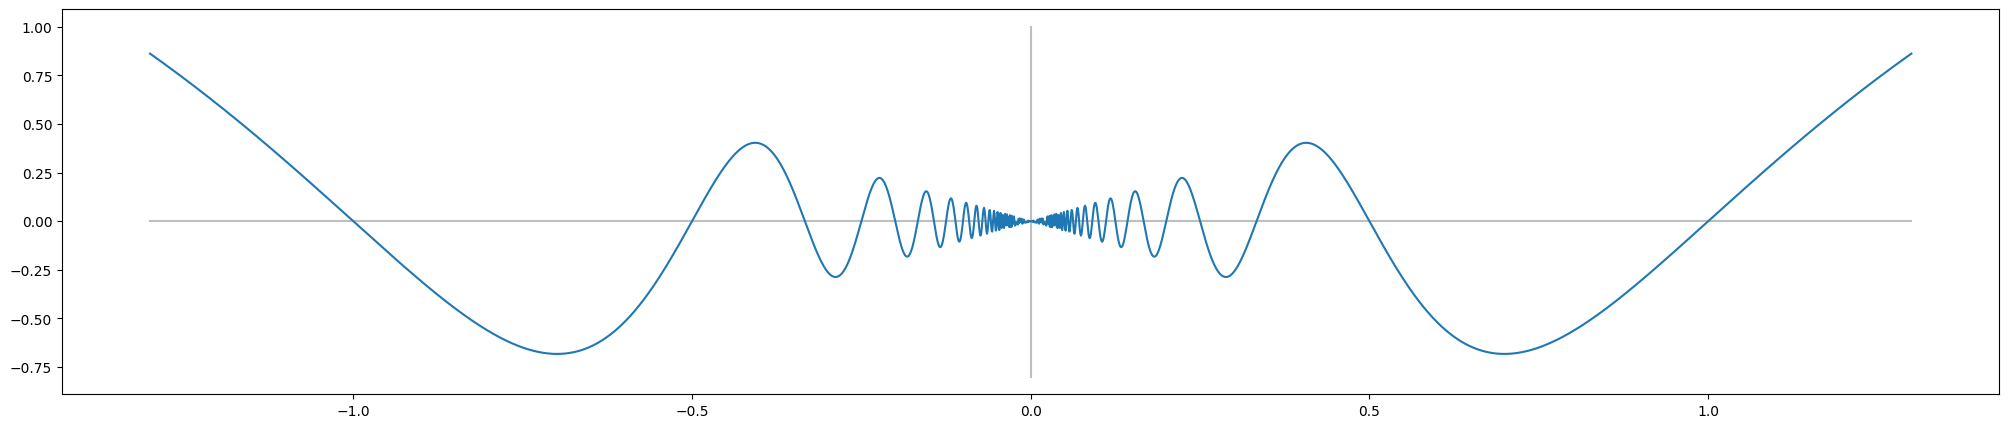

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def f(t: float) -> float:
    if t != 0:
        return t*np.sin(np.pi/t)
    else:
        return 0

x_vals = np.linspace(-1.3,1.3,3000)

plt.figure(figsize=(25,5))
sns.lineplot(x=[-1.3,1.3], y=[0,0], c='gray', alpha=0.5)
sns.lineplot(x=[0,0], y=[-0.8, 1], c='gray', estimator=None, alpha=0.5)
sns.lineplot(x=x_vals, y=[f(x) for x in x_vals])
plt.show()

However, what *is* true is that any continuous function $f(t)$ that starts at $f(0) > 0$ and later goes down to $f(t) < 0$ does have *some* point $t_0 \in (0,t)$ for which $f(t_0) = 0$ (This is called the *Intermediate Value Theorem*). It just may be that there are infinitely many such points.

## Homework Exercises

These are exercises intended to get you to review the material in this lecture. There are five questions and the intention is that, much like brushing teeth, you do one question a day. Give yourself 30 minutes of dedicated and undistracted time to try one problem a day. If it is taking longer than 30 minutes to do an exercise, stop for the day and come back to it, either later in the day, or to do as the problem for the next day. Ask for help if you are stuck. Please do one question *and only one question* a day. Doing more than one problem a day results in *overbrushing*.

I have assigned each homework a difficulty rating. Here is what they mean:
- 1/5 : You might be able to get away with solving this one without writing anything down.
- 2/5 : Should be easy, but you probably will need to write something down.
- 3/5 : A bit computationally tricky, and you might need to figure out a 'trick' to solve it.
- 4/5 : This will probably will take you some time to absorb the problem, and you shouldn't be surprised if it takes you more than one day to solve it.
- 5/5 : This is a hard problem.

### Homework Exercise 1 (Difficulty 1/5)
This exercise concerns calculations on the bra and ket space over the space of pairs $\mathbb{R}^2$. That is, for $v = (v_0, v_1) \in \mathbb{R}^2$, let $|v \rangle$ be the associated ket: as a vector this is just $v$, and it has the additional method $ev$. Let $\langle v|$ be the associated bra: this is the dual vector $\langle v | : V \to \mathbb{R}$ that such that
$$
    \langle v|(a,b) = v_0 \cdot a + v_1 \cdot b \;.
$$
Therefore, applying a ket to a bra gives us:
$$
    \langle (v_0, v_1) | (w_0, w_1) \rangle = v_0 \cdot w_0 + v_1 \cdot w_1 \;.
$$

1. Let $v = (1,2)$, $w = (-1, 2)$. Calculate $\langle v | w \rangle$.
2. Let $v = (1,2)$. Calculate $\langle v | v \rangle$.
3. Given any pair $v \in \mathbb{R}^2$, is it ever the case that $\langle v | v \rangle < 0$? If it is the case, give an example of such a $v$. If not, explain why not.
4. Given a pair $v \in\mathbb{R}^2$, when is it the case that $\langle v | v \rangle = 0$? That is, if $\langle v | v \rangle = 0$, what does that imply about $v$?
5. Given a pair $v \in \mathbb{R}^2$, when is it the case that $\langle v | v \rangle = 1$? What does this say about the length of the vector $v$ in the *line segment* picture for $v$ (see Exercise 2)?
6. Establish the identity $\langle v | w \rangle = \langle w | v \rangle$ for any $v,w \in \mathbb{R}^2$.

### Homework Exercise 2 (Difficulty 1/5)
This exercise concerns some 'trivial' checks for bras and kets.
1. Let $V$ be a vector space. Verify for $v,w \in V$, the identity
$$
    |v+w\rangle = |v \rangle + |w \rangle \;.
$$
(This is a 'trivial' check. Think about what this is asserting in terms of class inheritance).
2. Let $V$ be a vector space. Verify for $v \in V$ and scalar $\lambda$ the identity
$$
    |v \cdot \lambda \rangle = |v \rangle \cdot \lambda \;.
$$
(This is a 'trivial' check. Think about what this is asserting in terms of class inheritance).
3. Let $V$ be a vector space. Verify for $f,g \in V^*$ and a scalar $\lambda$ the identities
$$
    \langle f + g | = \langle f | + \langle g | \text{ and } \langle f \cdot \lambda | = \langle f| \cdot \lambda \;.
$$
(Again, this is a 'trivial' check for the same reasons as above).

4. Let $f,g \in V^*$ and $v,w \in V$. Show that
$$
    p_{f,g,v,w}(x) = \langle f + g \cdot x | v + w \cdot x \rangle
$$
is a quadratic polynomial in $x$. That is, find numbers $a,b,c$ (that involve $f,g,v,w$) so that $p_{f,g,v,w}(x) = ax^2 + bx +c$. Hint: This is the 'distributivity rule'.

### Homework Exercise 3 (Difficulty 4/5)
This is a follow-up to yesterday's exercise, where we look at the special case of $\mathbb{R}^2$. This exercise will heavily use the material about quadratic polynomials in the warm-up exercises.

1. Let $v,w \in \mathbb{R}^2$ and define the polynomial
$$
    p_{v,w}(x) = \langle v + w \cdot x| v + w \cdot x \rangle
$$
as in the previous example. Show that $p_{v,w}(x) \geq 0$ for every point $x$.
2. Show that if there is a number $x$ so that $p_{v,w}(x) = 0$ then $w \cdot (-x) = v$. In this case, establish the identity
$$
    \langle v | w \rangle^2 = \langle v | v \rangle \langle w | w \rangle \;.
$$
Hint: you may want to look at Homework Exercise 1 again.

3. Show that if $p_{v,w}(x)$ does *not* have a real root, then we have the inequality
$$
    \langle v | w \rangle^2 < \langle v | v \rangle \langle w | w \rangle \;.
$$
4. Deduce the Cauchy-Schwarz inequality: for any $v, w \in \mathbb{R}^2$, we have the inequality
$$
    \langle v | w \rangle^2 \leq \langle v | v \rangle \langle w | w \rangle
$$
with equality exactly when there is a scalar $\lambda$ such that $w \cdot \lambda = v$. Hint: a tautological statement is that a quadratic polynomial $p(x)$ either does or does not have a real root. Deduce something from either case.

The Cauchy-Schwarz inequality is one of the fundamental truths of mathematics. It, alongside the 'Hahn-Banach Theorem' are the two results that will make or break any analyst. The Cauchy-Schwarz inequality will be used later to establish *the* foundational result in quantum physics, called the Heisenberg uncertainty principle.

### Homework Exercise 4 (Difficulty 1/5)
These exercises introduce the idea of 'unit vectors'. For the following exercises, we work exclusively in $\mathbb{R}^2$.
1. A *unit vector* is a vector $v \in \mathbb{R}^2$ such that $\langle v | v \rangle = 1$. Show that $|+ \rangle = |(1,1)\cdot \frac{1}{\sqrt{2}} \rangle$ and $|- \rangle = |(1,-1) \cdot \frac{1}{\sqrt{2}} \rangle$ are unit vectors.
2. Let $|v\rangle$ be a vector. Use the Cauchy-Schwarz inequality from the previous exercise to show that $\langle v | v \rangle$ is the number that maximizes the value $\langle w | v \rangle$ for unit vectors $w \in \mathbb{R}^2$. That is, show that for all unit vectors $w$,
$$
    |\langle w | v \rangle | \leq \langle v | v \rangle \;.
$$
Deduce that for any unit vectors $v,w$, $\langle v | w \rangle$ is a number in between $-1$ and $1$.
3. Show that for every unit vector $v \in \mathbb{R}^2$, there is a number $\theta$ such that $|v \rangle = |(\cos(\theta),\sin(\theta))\rangle$. Hint: recall that if $x,y$ are numbers such that $x^2+y^2 = 1$, then there is a number $\theta$ such that $x =\cos(\theta)$ and $y = \sin(\theta)$.

We denote this vector by $|\theta \rangle = |(\cos(\theta),\sin(\theta))\rangle$.

4. Given two numbers $\theta_1, \theta_2$, use the identity $\cos(\alpha - \beta) = \cos(\alpha)\cos(\beta) + \sin(\alpha)\sin(\beta)$ to find a number $\omega$ such that
$$
    \langle \theta_1 | \theta_2 \rangle = \cos(\omega) \;.
$$
5. Show that for any vector $v \in \mathbb{R}^2$, one can write $v$ in the form $|v \rangle = |\theta \rangle \cdot \sqrt{\langle v | v \rangle}$ for some number $\theta$.

### Homework Exercise 5 (Difficulty 2/5)
In this exercise, we write down all of the orthonormal bases in $\mathbb{R}^2$. Recall a pair $|v \rangle, |w \rangle$ is an **orthonormal basis** in $\mathbb{R}^2$ if $|v \rangle$ and $|w \rangle$ are unit vectors with
$$
    \langle v | w \rangle = 0 \;.
$$
1. Use the identities
$$
\begin{align*}
    \cos(\alpha + \beta) &= \cos(\alpha)\cos(\beta) - \sin(\alpha)\sin(\beta) \text{ and} \\
    \sin(\alpha + \beta) &= \cos(\alpha)\sin(\beta) + \sin(\alpha)\cos(\beta)
\end{align*}
$$
along with the fact that $\cos(\pi/2) = 0$ and $\sin(\pi/2) = 1$ to show that for any number $\theta$,
$$
    |\theta + \pi/2 \rangle = |(-\sin(\theta), \cos(\theta) \rangle \text{ and } |\theta + \pi \rangle = -|\theta \rangle \;.
$$
2. Show that for any choice of $\theta$, $|\theta\rangle, |\theta+\pi/2 \rangle$ is an orthonormal basis for $\mathbb{R}^2$.
3. Show that if $|v\rangle, |w\rangle$ is an orthonormal basis for $\mathbb{R}^2$, and $\theta$ is such that $|v \rangle = |\theta \rangle$, then $|w \rangle = |\theta + k \cdot\pi/2 \rangle$ for some odd integer $k$. Hint: This is related to part 4 of the previous exercise.
4. Plot five examples of $|\theta \rangle, |\theta+\pi/2 \rangle$ (for your choice of five $\theta$) using Python. What do you notice?

# Solution to Warmup Exercises
### Solution to Warmup Exercise 1
1. The root is $x = 1$. Verify: $(x-1)(x-1) = x^2 - x - x + 1 = x^2 - 2x + 1 = p_1(x)$.
2. The root is $x = -1$. Verify: $(x+1)(x+1) = x^2 + x + x + 1 = x^2 + 2x + 1 = p_2(x)$.
3. The roots are $x_+ = \frac{-3 + \sqrt{17}}{4}$ and $x_- = \frac{-3 - \sqrt{17}}{4}$. Verify:
$$
\begin{align*}
    2\cdot(x - x_+) \cdot (x - x_-) &= 2 \cdot \left(x - \frac{-3 + \sqrt{17}}{4} \right)\cdot \left(x- \frac{-3 - \sqrt{17}}{4} \right) \\
    &= 2\left(x + \frac{3 - \sqrt{17}}{4} \right)\cdot \left(x+\frac{3 + \sqrt{17}}{4} \right) \\
    &= 2\left(x^2 + \frac{3 - \sqrt{17}}{4}x + \frac{3 + \sqrt{17}}{4}x + \frac{3 - \sqrt{17}}{4}\cdot \frac{3 + \sqrt{17}}{4}  \right) \\
   &= 2 \left( x^2 + \frac{3}{2}x + \frac{3 - \sqrt{17}}{4}\cdot \frac{3 + \sqrt{17}}{4}  \right) \;.
\end{align*}
$$
Using the fact that $\alpha^2 - \beta^2 = (\alpha +\beta)\cdot(\alpha -\beta)$ for any numbers $\alpha$ and $\beta$, we get 
$$
\begin{align*}
    2\cdot(x - x_+) \cdot (x - x_-) &= 2 \left( x^2 + \frac{3}{2}x + \frac{3^2 - \sqrt{17}^2}{4^2}  \right) \\
   &= 2x^2 + 3x + 2\cdot\frac{9-17}{16} \\
   &= 2x^2 + 3x - 1 \\
   &= p_3(x) \;.
\end{align*}
$$
4. The roots are $x_+ = \frac{-5 + \sqrt{41}}{2}$ and $x_- = \frac{-5 - \sqrt{41}}{2}$. Verify:
$$
\begin{align*}
    (x-x_+)\cdot(x-x_-) &= \left(x - \frac{-5 + \sqrt{41}}{2}\right)\cdot\left(x- \frac{-5 - \sqrt{41}}{2}\right) \\
   &=  x^2 - (-5)x + \frac{-5 + \sqrt{41}}{2}\cdot\frac{-5 - \sqrt{41}}{2} \\
   &= x^2 +5x + \frac{(-5)^2 - \sqrt{41}^2}{2^2} \\
   &= x^2 + 5x + \frac{25 - 41}{4} \\
   &= x^2 + 5x - \frac{16}{4} \\
   &= x^2 + 5x - 4 \\
   &= p_4(x) \;.
\end{align*}
$$

### Solution to Warmup Exercise 2
1. $\Delta(p_1) = (3)^2 - 4\cdot 1 \cdot 9 = 9 - 4 \cdot 9  = -3 \cdot 9 < 0$ so no real roots.
2. $\Delta(p_2) = (-3)^2 - 4 \cdot 1 \cdot 9 = -3 \cdot 9 < 0$  so no real roots.
3. $\Delta(p_3) = (14)^2 - 4 \cdot 2 \cdot 56 = 196 - 4\cdot 108 < 0$ so no real roots.
4. $\Delta(p_4) = (8)^2 - 4 \cdot 1 \cdot (-2) = 64 + 8 > 0$ so has real roots.

If $a > 0$ and $c < 0$, then the discriminant is $\Delta(p) = b^2 -4 \cdot a \cdot c = b^2 + 4 \cdot a \cdot (-c)$. Since $-c > 0$ and $a > 0$, the fact that products of positive numbers yield a positive number gives us $4 \cdot a \cdot (-c) > 0$. As well, $b^2 \geq 0$ for any $b$. Therefore, $\Delta(p) =  b^2 + 4 \cdot a \cdot (-c) > 0$ and we can conclude that $p(x)$ has real roots.

### Solution to Warmup Exercise 3

1. Since $\cos(\pi/2) = 0$, we get that $\cos(\pi/2)^2 + \sin(\pi/2)^2 = 0^2 + \sin(\pi/2)^2 = 1$. That is, $\sin(\pi/2) = 1$ or $\sin(\pi/2) = -1$. By our rule 3, $\sin(\pi/2) > 0$, and thus, $\sin(\pi/2) =1$.
2. This is the sum of angles identity with $\beta = \pi/2$. In this case,
$$
    \cos(\alpha + \pi/2) = \cos(\alpha)\cos(\pi/2) - \sin(\alpha)\sin\pi/2) = \cos(\alpha)\cdot 0 - \sin(\alpha)\cdot 1 = -\sin(\alpha)\;.
$$
Similarly,
$$
    \sin(\alpha + \pi/2) = \sin(\alpha)\cos(\pi/2) + \sin(\pi/2)\cos(\alpha) = \sin(\alpha)\cdot 0 + 1\cdot\cos(\alpha) = \cos(\alpha)\;.
$$
3. Using the previous problem,
$$
    \cos(\alpha + \pi) = \cos((\alpha + \pi/2) + \pi/2) = -\sin(\alpha+\pi/2) = -\cos(\alpha) \;.
$$
The other identities follow the same logic.

4.
- This follows from setting $\beta = -\alpha$.
- This is a calculation:
$$
\begin{align*}
    \cos(\alpha)f(\alpha) + \sin(\alpha)g(\alpha) &= \cos(\alpha)\cdot(\cos(\alpha)\cos(-\alpha) - \sin(\alpha)\sin(-\alpha))  \\
    &+ \sin(\alpha)(\sin(\alpha)\cos(-\alpha)+\cos(\alpha)\sin(-\alpha)) \\
    &= \cos(\alpha)^2\cos(-\alpha) - {\color{red} \cos(\alpha)\sin(\alpha)\sin(-\alpha)} \\
    &+ \sin(\alpha)^2\cos(-\alpha) + {\color{red} \sin(\alpha)\cos(\alpha)\sin(-\alpha)} \;.
\end{align*}
$$
Notice that the red terms cancel out. This leaves us with
$$
\begin{align*}
    \cos(\alpha)f(\alpha) + \sin(\alpha)g(\alpha) &= (\cos(\alpha)^2 + \sin(\alpha)^2)\cos(-\alpha) = \cos(-\alpha) \;.
\end{align*}
$$
On the other hand, $f(\alpha) =1$ and $g(\alpha) = 0$. Thus, the left hand side reduces to
$$
    \cos(\alpha)\cdot 1 + \sin(\alpha)\cdot 0 = \cos(\alpha) \;,
$$
establishing the identity. The same line of reasoning establishes $\sin(-\alpha) = - \sin(\alpha)$.

5. Let $\alpha = \beta = \pi/4$. The sum of angles formula tell us
$$
\begin{align*}
    0 &= \cos(\pi/2) = \cos(\pi/4 + \pi/4) = \cos(\pi/4)^2 - \sin(\pi/4)^2 \\
    1 &= \sin(\pi/2) = 2\cos(\pi/4)\sin(\pi/4) \;.
\end{align*}
$$
The first identity in particular tells us that $\cos(\pi/4)^2 = \sin(\pi/4)^2$. Along with the fact that $\cos(t)^2 + \sin(t)^2 = 1$ for all $t$, we get that $\cos(\pi/4)^2 = \frac{1}{2}$. Thus, $\cos(\pi/4) = \frac{1}{\sqrt{2}}$ or $\cos(\pi/4) = - \frac{1}{\sqrt{2}}$. Since $\pi/2 > \pi/4 > 0$, $\cos(\pi/4) > 0$. Thus, $\cos(\pi/4) = \frac{1}{\sqrt{2}}$. The same line of reasoning with the fact that $\sin(\pi/4) > 0$ tell us $\sin(\pi/4) = \frac{1}{\sqrt{2}}$.